# Penalty Shootout Simulator — Monte Carlo Analysis

## Background
In a penalty shootout, each team takes up to 5 kicks. Whichever 
team scores more after 5 kicks wins. If level after 5 kicks each 
team alternates kicks until one scores and the other doesn't.

Historical conversion rate: approximately 75%.

Binomial distribution is used because penalty kicks have a fixed 
number of tries. Poisson is used when there is no fixed limit.

## Question
If two equally skilled teams both convert at 75% what is the 
probability that each team wins? And how does that change as 
the conversion rate changes?

## Why this matters
This is the same class of model Tony Bloom uses at StarLizard 
for match outcome simulation. The technique is to simulate many 
times, count results and apply to any probabilistic football 
event. This is the foundation of everything.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
#Simulate n penalty shootouts
#Returns arrays: 0 = team_A wins, 1 = team_B wins.
def simulate_shootout(p_convert = 0.75, n_sims = 10_000):
    results = []
    #Each team has 5 kicks
    #random() generates random numbers between 0 and 1. A penalty kick is scored when a random number generated < p_convert
    for _ in range(n_sims):
        a = (np.random.random(5) < p_convert).sum()
        b = (np.random.random(5) < p_convert).sum()
        if a != b:
            results.append(0 if a < b else 1)
        #Sudden death scenario
        else:
            #Taken another kick if both teams score or miss
            while True:
                kick_a = np.random.random() < p_convert
                kick_b = np.random.random() < p_convert
                if kick_a and not kick_b:
                    results.append(0); break
                elif kick_b and not kick_a:
                    results.append(1); break
    return np.array(results)
results = simulate_shootout(n_sims = 10_000)
print(f'Team A wins: {(results == 0).mean():.1%}')
print(f'Team B wins: {(results == 1).mean():.1%}')
            
            


Team A wins: 49.7%
Team B wins: 50.3%


**Does skill matter?**

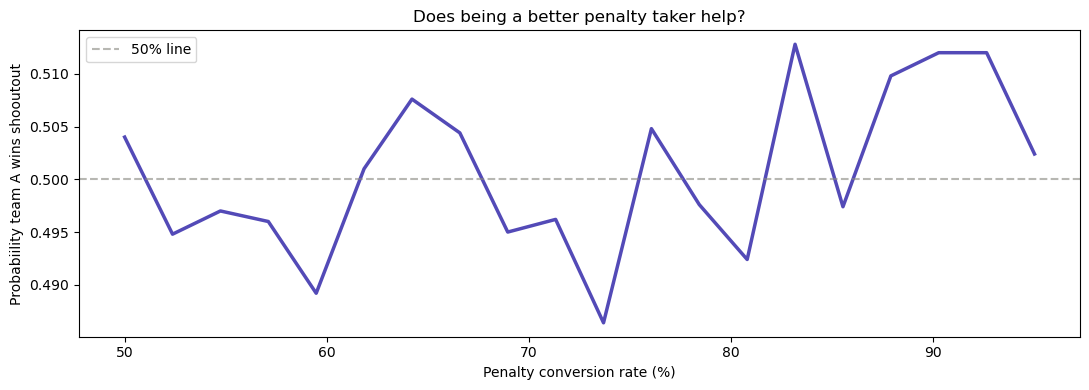

In [2]:
#Conversion rate from 50%(worst penalty taker) to 95% (best penalty taker)
rates = np.linspace(0.50,0.95,20)
win_probs = [ ]
for rate in rates:
    r = simulate_shootout(p_convert = rate, n_sims = 5000)
    win_probs.append((r==0).mean())
fig,ax = plt.subplots(figsize = (11,4))
#Chart 1: Conversion rate vs win probability
ax.plot(rates * 100, win_probs, color = '#534AB7', linewidth = 2.5)
ax.axhline(0.5, color = '#888780', linestyle = '--' , alpha = 0.6, label = '50% line')
ax.set_xlabel('Penalty conversion rate (%)')
ax.set_ylabel('Probabiility team A wins shooutout')
ax.set_title('Does being a better penalty taker help?')
ax.legend()
plt.tight_layout()
plt.savefig('shootout_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Even elite penalty takers do not always score from 5 kicks. 
The best miss. The worst get lucky. That is enough to make 
the outcome anyone's game. Here is the evidence:**

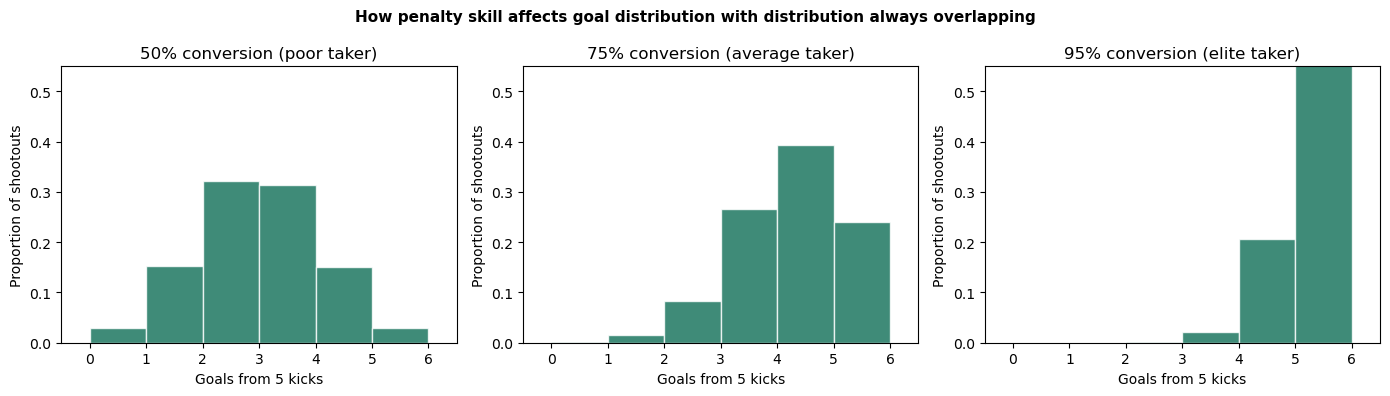

In [3]:
fig,axes = plt.subplots(1,3, figsize = (14,4))

rates_to_show = [0.50, 0.75, 0.95]
titles = ['50% conversion (poor taker)',
          '75% conversion (average taker)',
          '95% conversion (elite taker)']
for ax, rate, title in zip(axes, rates_to_show, titles):
    goals = np.random.binomial(n = 5, p = rate, size= 10_000)
    ax.hist(goals,bins = range(0,7), density = True,
            color = '#0F6E56', alpha = 0.8, edgecolor = 'white')
    ax.set_xlabel('Goals from 5 kicks')
    ax.set_ylabel('Proportion of shootouts')
    ax.set_title(title)
    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(0, 0.55)

plt.suptitle('How penalty skill affects goal distribution with distribution always overlapping',
            fontsize = 11, fontweight = 'bold')
plt.tight_layout()
plt.savefig('shootout_distributions.png', dpi = 150, bbox_inches = 'tight')
plt.show()

**Findings**

The three charts above show why shootouts are near-random events.

A poor taker most often scores 2 to 3 goals from 5 kicks

An average taker most often scores 3 to 4 goals from 5 kicks

An elite taker most often scores 4 to 5 goals from 5 kicks

However, a poor taker can also score 4 goals from 5 kicks and beat an elite taker who scores 3 goals from 5 kicks

Penalty shootouts are not won by the better penalty taker 

They are won by whoever gets lucky on the day.